In [37]:
import os
import shutil
import kagglehub

# 1. Your token is working perfectly!
os.environ['KAGGLE_API_TOKEN'] = "KGAT_0035d60d198022b516959b4721ff2ea7"

# 2. Download the CORRECT dataset 
print("Downloading dataset...")
download_path = kagglehub.dataset_download("dionisiusdh/indonesian-batik-motifs")

# 3. Move it to our working folder so the rest of our code works
shutil.copytree(download_path, "batik_dataset", dirs_exist_ok=True)

print("Dataset downloaded and ready in the 'batik_dataset' folder!")

Using Colab cache for faster access to the 'indonesian-batik-motifs' dataset.
Dataset downloaded and ready in the 'batik_dataset' folder!


In [43]:
import os
from PIL import Image

data_dir = 'batik_dataset'
print("Starting Deep Cleaning...")

removed_count = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            # Try to physically open and verify the image data
            img = Image.open(file_path)
            img.verify() 
        except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
            # If the file is corrupted or not a real image, delete it
            os.remove(file_path)
            removed_count += 1
            print(f"Removed broken file: {file_path}")

print(f"Done! Deep cleaning removed {removed_count} problematic files.")

Starting Deep Cleaning...
Removed broken file: batik_dataset/batik-cendrawasih/18.jpg
Removed broken file: batik_dataset/batik-megamendung/49.jpg
Done! Deep cleaning removed 2 problematic files.


In [44]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Define parameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
DATA_DIR = 'batik_dataset'

# 1. Create the Training Dataset (80% of the data)
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Create the Validation Dataset (20% of the data)
val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 3. Get the list of Batik Motif names
class_names = train_ds.class_names
print(f"Batik motifs found: {class_names}")

# 4. Optimize performance by loading data into memory (Autotune)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 981 files belonging to 20 classes.
Using 785 files for training.
Found 981 files belonging to 20 classes.
Using 196 files for validation.
Batik motifs found: ['batik-bali', 'batik-betawi', 'batik-celup', 'batik-cendrawasih', 'batik-ceplok', 'batik-ciamis', 'batik-garutan', 'batik-gentongan', 'batik-kawung', 'batik-keraton', 'batik-lasem', 'batik-megamendung', 'batik-parang', 'batik-pekalongan', 'batik-priangan', 'batik-sekar', 'batik-sidoluhur', 'batik-sidomukti', 'batik-sogan', 'batik-tambal']


In [45]:
from tensorflow.keras import layers, models

# 1. Define the Baseline Architecture
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)), # Normalize pixels to [0,1]
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax') # Output layer for 20 classes
])

# 2. Compile
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model for 10 epochs
print("Starting training...")
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Starting training...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.0404 - loss: 7.7166 - val_accuracy: 0.0408 - val_loss: 2.9684
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1016 - loss: 2.8901 - val_accuracy: 0.1020 - val_loss: 2.9111
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3787 - loss: 2.5015 - val_accuracy: 0.1531 - val_loss: 2.9594
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6477 - loss: 1.5147 - val_accuracy: 0.1633 - val_loss: 3.3407
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8691 - loss: 0.8214 - val_accuracy: 0.1990 - val_loss: 3.8675
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9204 - loss: 0.5175 - val_accuracy: 0.1429 - val_loss: 4.6582
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9503 - loss: 0.3532 - val_accuracy: 0.1735 - val_loss: 4.5827
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9552 - loss: 0.4021 - v

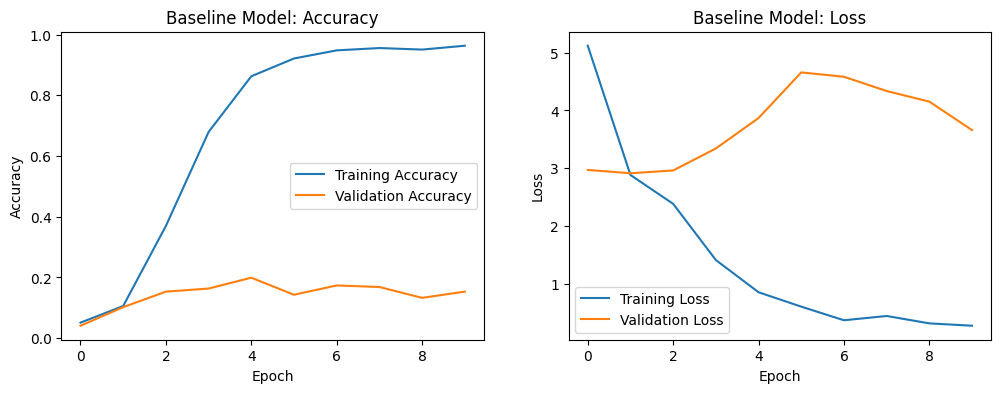

In [46]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 4))

# 1. Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

# 1. Load the pre-trained MobileNetV2 (leaving out the top classification layer)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

# 2. Freeze the base model (keep the "intelligence" it already has)
base_model.trainable = False

# 3. Add your custom layers for the 20 Batik classes
mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # This helps stop the overfitting you saw earlier!
    layers.Dense(len(class_names), activation='softmax')
])

# 4. Compile
mobilenet_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# 5. Train for 10 epochs
print("Starting MobileNetV2 Transfer Learning...")
history_mobile = mobilenet_model.fit(train_ds,
                                    validation_data=val_ds,
                                    epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting MobileNetV2 Transfer Learning...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.0579 - loss: 3.4714 - val_accuracy: 0.1327 - val_loss: 2.9362
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1711 - loss: 2.7927 - val_accuracy: 0.1786 - val_loss: 2.6863
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2585 - loss: 2.5640 - val_accuracy: 0.2041 - val_loss: 2.6100
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2583 - loss: 2.4346 - val_accuracy: 0.2194 - val_loss: 2.5797
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3191 - loss: 2.2327 - val_accuracy: 0.2500 - val_loss: 2.5089
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3201 - loss: 2.1718 - val_accuracy: 0.2296 - val_loss: 2.5224
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4038 - loss: 2.0049 - val_accuracy: 0.2551 - val_loss: 2.4977
Epoch 8/10
25/25 ━━━━

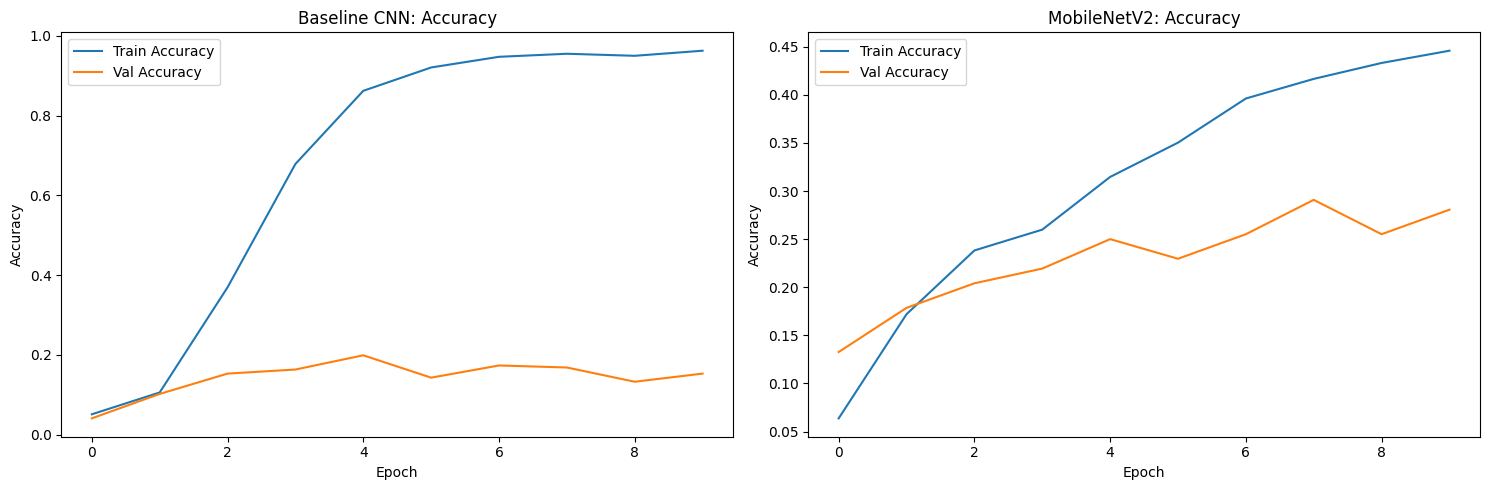

In [48]:
import matplotlib.pyplot as plt

def plot_history(histories, titles):
    plt.figure(figsize=(15, 5))
    for i, (history, title) in enumerate(zip(histories, titles)):
        plt.subplot(1, len(histories), i+1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
        plt.title(f'{title}: Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
    plt.tight_layout()
    plt.show()

# Run the plot
plot_history([history, history_mobile], ['Baseline CNN', 'MobileNetV2'])

In [49]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Refreeze everything EXCEPT the last 20 layers 
# (This keeps the "basic" knowledge safe while training the "complex" part)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compile with a MUCH lower learning rate
# We use 1e-5 (0.00001) so we don't destroy the pre-trained weights
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Continue training for another 10 epochs
print("Starting Fine-Tuning...")
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_fine = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_mobile.epoch[-1], # Start from where we left off
    epochs=total_epochs
)

Starting Fine-Tuning...
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 838ms/step - accuracy: 0.1271 - loss: 3.9180 - val_accuracy: 0.2653 - val_loss: 2.4699
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1472 - loss: 3.5695 - val_accuracy: 0.2500 - val_loss: 2.4833
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1671 - loss: 3.1799 - val_accuracy: 0.2551 - val_loss: 2.5070
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2050 - loss: 2.9207 - val_accuracy: 0.2500 - val_loss: 2.5308
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2730 - loss: 2.5070 - val_accuracy: 0.2449 - val_loss: 2.5566
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3490 - loss: 2.2758 - val_accuracy: 0.2449 - val_loss: 2.5769
Epoch 16/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3993 - loss: 2.0829 - val_accuracy: 0.2500 - val_loss: 2.6025
Epoch 17/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4561 - loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


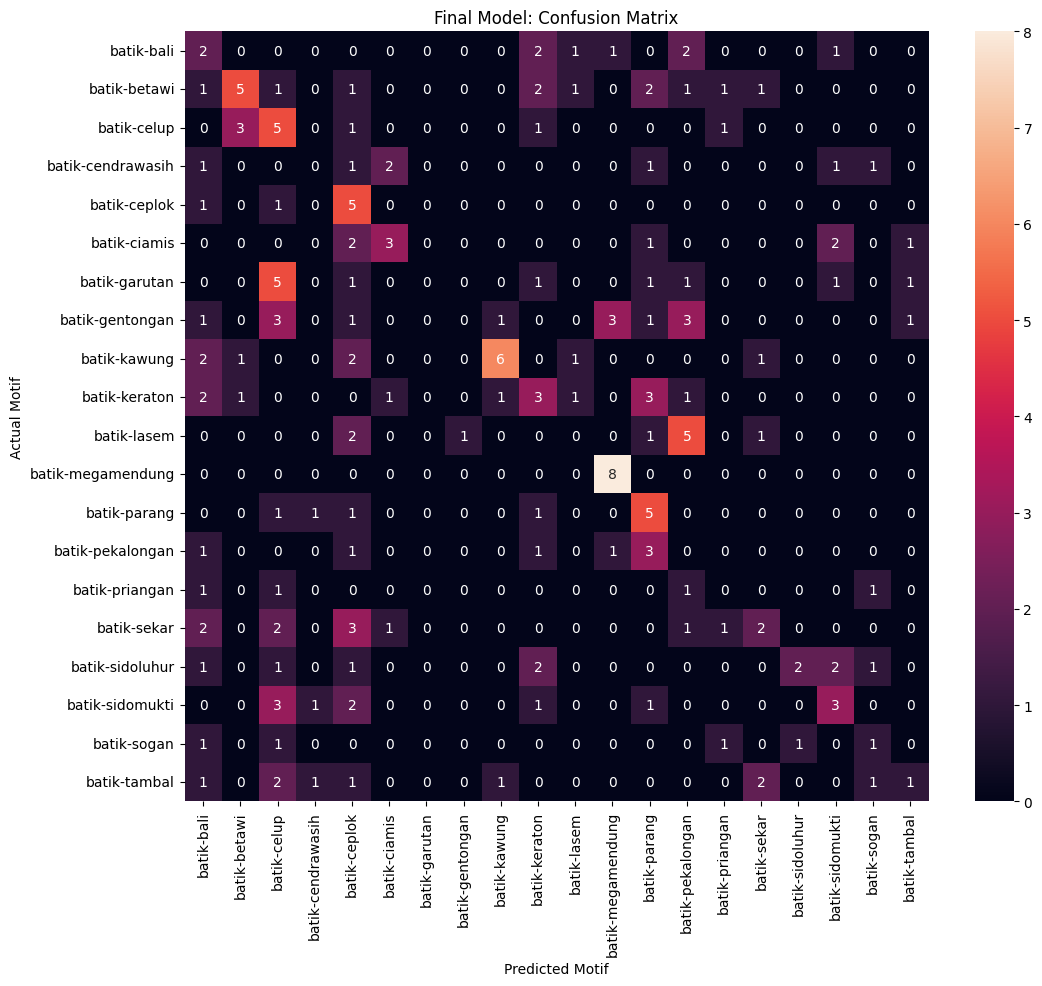

                   precision    recall  f1-score   support

       batik-bali       0.12      0.22      0.15         9
     batik-betawi       0.50      0.31      0.38        16
      batik-celup       0.19      0.45      0.27        11
batik-cendrawasih       0.00      0.00      0.00         7
     batik-ceplok       0.20      0.71      0.31         7
     batik-ciamis       0.43      0.33      0.38         9
    batik-garutan       0.00      0.00      0.00        11
  batik-gentongan       0.00      0.00      0.00        14
     batik-kawung       0.67      0.46      0.55        13
    batik-keraton       0.21      0.23      0.22        13
      batik-lasem       0.00      0.00      0.00        10
batik-megamendung       0.62      1.00      0.76         8
     batik-parang       0.26      0.56      0.36         9
 batik-pekalongan       0.00      0.00      0.00         7
   batik-priangan       0.00      0.00      0.00         4
      batik-sekar       0.29      0.17      0.21       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions for the validation set
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = mobilenet_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 2. Plot the Heatmap
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Model: Confusion Matrix')
plt.ylabel('Actual Motif')
plt.xlabel('Predicted Motif')
plt.show()

# 3. Print the full report
print(classification_report(y_true, y_pred, target_names=class_names))

In [51]:
# Save the model as a standard Keras file
mobilenet_model.save('batik_expert_model.h5')
print("Model saved successfully as batik_expert_model.h5")

Model saved successfully as batik_expert_model.h5


In [ ]:
import tensorflow as tf

# 1. Load the model you saved earlier
# Make sure 'batik_expert_model.h5' is visible in your Colab sidebar!
mobilenet_model = tf.keras.models.load_model('batik_expert_model.h5')

# 2. Re-define the class names so the model can label the result
class_names = ['batik-bali', 'batik-betawi', 'batik-celup', 'batik-cendrawasih', 
               'batik-ceplok', 'batik-ciamis', 'batik-garutan', 'batik-gentongan', 
               'batik-kawung', 'batik-keraton', 'batik-lasem', 'batik-megamendung', 
               'batik-parang', 'batik-pekalongan', 'batik-priangan', 'batik-sekar', 
               'batik-sidoluhur', 'batik-sidomukti', 'batik-sogan', 'batik-tambal']

print("Model and Class Names reloaded successfully!")

Available files: ['.config', 'batik_expert_model.h5', 'batik_dataset', 'sample_data']
Error: Still can't see 'test_batik.jpg'. Try right-clicking the file in the sidebar and selecting 'Copy Path', then paste it into the image_path variable.


In [ ]:
from google.colab import files
import os
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. This opens a 'Choose File' button in your browser
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Preprocess the image you just picked
    img = image.load_img(filename, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0 

    # 3. Predict using your loaded MobileNetV2 model
    classes = mobilenet_model.predict(x)
    result = np.argmax(classes[0])

    # 4. Show the result for THIS specific file
    print(f"\n--- Prediction Result ---")
    print(f"File Name: {filename}")
    print(f"Detected Motif: {class_names[result]}")
    print(f"Confidence: {classes[0][result]*100:.2f}%")
    print("-" * 30)